## Rung 4

(7-12 mins)

### HAPI Client

#### Task 36: Plotting Total Solar Irradiance HAPI Data
 - **Description:** Use hapiplot to plot Total Solar Irradiance from 1950 to the present day, via the Historical TSI dataset in LISIRD's HAPI server.
 - **Expected Learning Outcome:** Finding data in the LISIRD HAPI catalog, basic plotting with hapiplot.
 - **Hints:** Use the hapi() and/or hapiplot() functions; don't code the plot from scratch by hand.

0.2.2


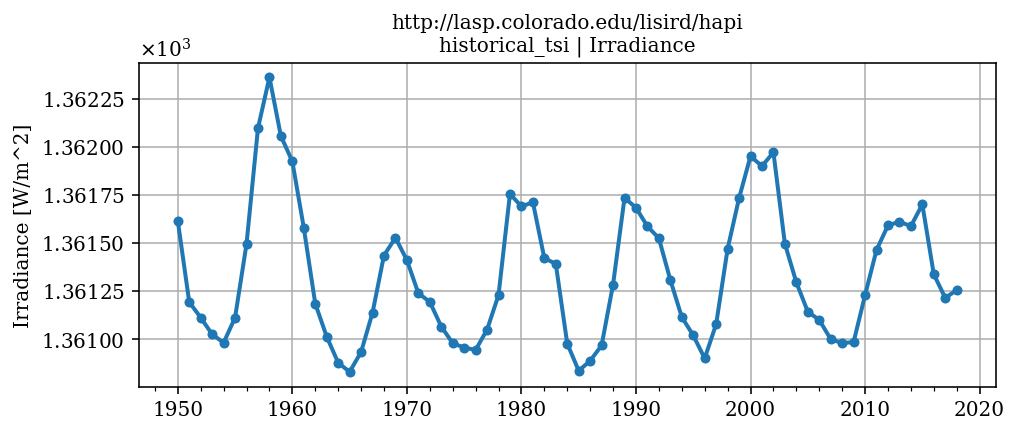

{'HAPI': '2.0',
 'status': {'code': 1200, 'message': 'OK'},
 'parameters': [{'name': 'time',
   'type': 'isotime',
   'length': 24,
   'units': 'UTC',
   'fill': None},
  {'name': 'Irradiance',
   'type': 'double',
   'units': 'W/m^2',
   'fill': None,
   'hapiplot': {'figure': <Figure size 1008x432 with 1 Axes>}}],
 'startDate': '1610-01-01T00:00:00.000Z',
 'stopDate': '2018-12-31T00:00:00.000Z',
 'x_server': 'http://lasp.colorado.edu/lisird/hapi',
 'x_dataset': 'historical_tsi',
 'x_parameters': 'time,Irradiance',
 'x_time.min': '1950Z',
 'x_time.max': '2024Z',
 'x_requestDate': '2024-05-17T20:00:18',
 'x_cacheDir': '/tmp/hapi-data/lasp.colorado.edu_lisird_hapi',
 'x_downloadTime': 0.38946080207824707,
 'x_readTime': 0.0025022029876708984,
 'x_metaFileParsed': '/tmp/hapi-data/lasp.colorado.edu_lisird_hapi/historical_tsi___.pkl',
 'x_dataFileParsed': '/tmp/hapi-data/lasp.colorado.edu_lisird_hapi/historical_tsi_time,Irradiance_1950_2024.npy',
 'x_metaFile': '/tmp/hapi-data/lasp.colorad

In [1]:
# Idealized developer minutes: 7

# %pip install hapiplot --upgrade

from hapiclient import hapi
from hapiplot import hapiplot

from importlib.metadata import version

print(version('hapiplot'))

servers = hapi()  # reveals LISIRD URL: http://lasp.colorado.edu/lisird/hapi
server = 'http://lasp.colorado.edu/lisird/hapi'
catalog = hapi(server)  # reveals dataset name: historical_tsi
dataset = 'historical_tsi'
parameters = hapi(server, dataset)  # reveals parameter names: time, Irradiance
parameters = 'time,Irradiance'
start = '1950'
stop = '2024'

data, meta = hapi(server, dataset, parameters, start, stop)
hapiplot(data, meta)

#### Task 37: Converting to Pandas DataFrame
 - **Description:** Download the following dataset, then convert it to store the data in a Pandas DataFrame. Use the hapitime2datetime() function to convert time values to Python datetime objects. The resulting DataFrame must use time as the index, and the columns must be named 'Time', 'scalar','vector_x', 'vector_y', 'vector_z'.
     - Server: "http://hapi-server.org/servers/TestData2.0/hapi"
     - Dataset: "dataset1"
     - Parameters: "scalar", "vector"
     - Start time: 12:00:00 AM January 1st, 1970 UTC
     - Stop time: 12:00:10 AM January 1st, 1970 UTC
 - **Expected Learning Outcome:** Using hapitime2datetime(), converting HAPI data to a Pandas DataFrame.
 - **Hints:** You can pass all time values at once to hapitime2datetime().

In [2]:
# Idealized developer minutes: 8

from hapiclient import hapi
from hapiclient import hapitime2datetime
import pandas

server     = 'http://hapi-server.org/servers/TestData2.0/hapi'
dataset    = 'dataset1'
parameters = 'scalar,vector'
start      = '1970-01-01T00:00:00Z'
stop       = '1970-01-01T00:00:10Z'

data, meta = hapi(server,dataset,parameters,start,stop)

df_Time = pandas.DataFrame(hapitime2datetime(data['Time']))
df_scalar = pandas.DataFrame(data['scalar'])
df_vector = pandas.DataFrame(data['vector'])

# Create DataFrame
df = pandas.DataFrame()

# Combine DataFrame
df = pandas.concat([df_Time, df_scalar, df_vector], axis=1)

# Name columns
df.columns = ['Time', 'scalar','vector_x', 'vector_y', 'vector_z']

# Set Time to be index
df.set_index('Time', inplace=True)
df

,scalar,vector_x,vector_y,vector_z
Time,,,,
1970-01-01 00:00:00+00:00,0.000000,0.000000,-0.707107,-1.000000
1970-01-01 00:00:01+00:00,0.005236,0.005236,-0.703395,-0.999986
1970-01-01 00:00:02+00:00,0.010472,0.010472,-0.699663,-0.999945
1970-01-01 00:00:03+00:00,0.015707,0.015707,-0.695913,-0.999877
1970-01-01 00:00:04+00:00,0.020942,0.020942,-0.692143,-0.999781
1970-01-01 00:00:05+00:00,0.026177,0.026177,-0.688355,-0.999657
1970-01-01 00:00:06+00:00,0.031411,0.031411,-0.684547,-0.999507
1970-01-01 00:00:07+00:00,0.036644,0.036644,-0.680721,-0.999328
1970-01-01 00:00:08+00:00,0.041876,0.041876,-0.676876,-0.999123


#### Task 38: Coordinate Transform with SpacePy
 - **Description:** Starting with the following program,
    1. Print out the GSE and GSM values reported by SSCWeb.
    2. Use SpacePy to convert the GSE values to GSM.
```
import spacepy.coordinates as sc
from spacepy.time import Ticktock

from hapiclient import hapi, hapitime2datetime

server     = 'https://hapi-server.org/servers/SSCWeb/hapi'
dataset    = 'swarma'
parameters = 'X_GSE,Y_GSE,Z_GSE,X_GSM,Y_GSM,Z_GSM'
start      = '2013-11-26T00:00:00Z'
stop       = '2013-11-26T00:01:00Z'

opts       = {'logging': True, 'usecache': True, 'cachedir': './hapicache'}

data, meta = hapi(server, dataset, parameters, start, stop)
print(data)
```
 - **Expected Learning Outcome:** Using SpacePy to transform HAPI data coordinates. 
 - **Hints:** Use HAPI's hapitime2datetime() function, and SpacePy's sc.Coords(), Ticktock(), convert() functions.

In [3]:
# Idealized developer minutes: 10

import spacepy.coordinates as sc
from spacepy.time import Ticktock

from hapiclient import hapi, hapitime2datetime

server     = 'https://hapi-server.org/servers/SSCWeb/hapi'
dataset    = 'swarma'
parameters = 'X_GSE,Y_GSE,Z_GSE,X_GSM,Y_GSM,Z_GSM'
start      = '2013-11-26T00:00:00Z'
stop       = '2013-11-26T00:01:00Z'

opts       = {'logging': True, 'usecache': True, 'cachedir': './hapicache'}

data, meta = hapi(server, dataset, parameters, start, stop)

xyz_gse = [data['X_GSE'][0],data['Y_GSE'][0],data['Z_GSE'][0]]
xyz_gsm = [data['X_GSM'][0],data['Y_GSM'][0],data['Z_GSM'][0]]

inp = sc.Coords(xyz_gse, 'GSE', 'car')

datetimes = hapitime2datetime(data['Time'])

# Convert from YYYY-DOY to YYYY-MM-DD date format needed by SpacePy
inp.ticks = Ticktock([datetimes[0].strftime('%Y-%m-%dT%H:%M:%S.%f')], 'ISO')

output = inp.convert('GSM', 'car')
xyz_gsm_spacepy = output.data[0]

print('             X_GSE       Y_GSE       Z_GSE ')
print('SSCWeb:  {0:11.8f} {1:11.8f} {2:11.8f}'.format(*xyz_gse))

print('\n')

print('             X_GSM       Y_GSM       Z_GSM ')
print('SSCWeb:  {0:11.8f} {1:11.8f} {2:11.8f}'.format(*xyz_gsm))
print('SpacePy: {0:11.8f} {1:11.8f} {2:11.8f}'.format(*xyz_gsm_spacepy))

             X_GSE       Y_GSE       Z_GSE 
SSCWeb:  -0.90768694 -0.56790949  0.11797884


             X_GSM       Y_GSM       Z_GSM 
SSCWeb:  -0.90768694 -0.56617595  0.12603571
SpacePy: -0.90768694 -0.56620550  0.12590287


### pySPEDAS

#### Task 40: T89 Field Modeling Versus THEMIS Observations
 - **Description:** Compare T89 model values to real THEMIS observations. Using pySPEDAS, load THEMIS state data for probe A, 2023-03-24, in GSM coordinates. Then, using the T89 model, generate the expected field at the THEMIS-A times and GSM positions (using the default model parameters). Then load THEMIS-A FGM spin fit data for the same time range. Calculate the difference between the observed and modeled field variables using `pytplot.subtract()`. Set the `yrange` of the difference variable to `[-200.0, 200.0] nT`. Plot the position variable, modeled field variable, observed field variable, and observed-modeled field difference.
 - **Expected Learning Outcome:** How to compare THEMIS to the T89 field model.
 - **Hints:** pyspedas.themis.state, varnames="tha_pos_gsm"; from pyspedas.geopack import tt89; tt89(position_variable) (Output: position_variable + '_bt89'); pyspedas.themis.fgm; pytplot.options, "yrange"

Load IGRF coefficients ...
File is current: themis_data/tha/l1/state/2023/tha_l1_state_20230324.cdf
['tha_pos_gsm']
File is current: themis_data/tha/l2/fgm/2023/tha_l2_fgm_20230324_v01.cdf


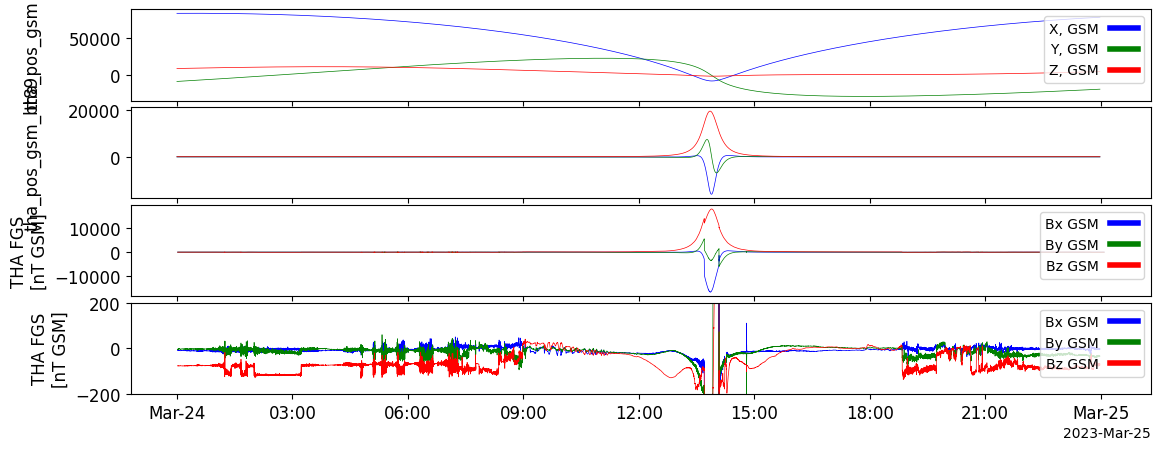

In [5]:
# Idealized developer minutes: 7+?

import pyspedas
from pyspedas.geopack import tt89
from pytplot import tplot, subtract, options

trange = ["2023-03-24","2023-03-25"]
state_vars = pyspedas.themis.state(probe='a',trange=trange,varnames=["tha_pos_gsm"])
print(state_vars)
tt89('tha_pos_gsm')

fgm_vars = pyspedas.themis.fgm(probe='a',trange=trange)

subtract('tha_fgs_gsm','tha_pos_gsm_bt89','mag_diff')

options('mag_diff', 'yrange', [-200.0, 200.0])

tplot(["tha_pos_gsm","tha_pos_gsm_bt89", "tha_fgs_gsm", "mag_diff"])

#### Task 41: T96 Field Modeling Versus MMS Observations (ORIG)
 - **Description:** Compare T96 model values to real MMS observations. Using pySPEDAS, load MMS orbit data for probe 1 on 2023-03-24, in GSM coordinates. Then download T96 model parameters from OMNI and the Kyoto WDC. Then, using the T96 model, generate the expected field at the MMS-1 times and GSM positions (using the downloaded model parameters). Then load MMS-1 FGM survey data in GSM coordinates for the same time range. Calculate the difference between the observed and modeled field variables using `pytplot.subtract()`. Set the `yrange` of the difference variable to `[-200.0, 200.0] nT`. Plot the position variable, modeled field variable, observed field variable, and observed-modeled field difference.

 Use this helper function:
 ```python
def get_params(trange):
    support_trange = [time_double(trange[0])-60*60*24, 
                      time_double(trange[1])+60*60*24]
    pyspedas.kyoto.dst(trange=support_trange)
    pyspedas.omni.data(trange=support_trange)
    join_vec(['BX_GSE', 'BY_GSM', 'BZ_GSM'])
    return get_tsy_params('kyoto_dst',
                          'BX_GSE-BY_GSM-BZ_GSM_joined',
                          'proton_density',
                          'flow_speed',
                          model='t96',
                          pressure_tvar='Pressure',
                          g_variables=None,
                          speed=True)
 ```
 - **Expected Learning Outcome:** How to compare MMS to the T96 field model.
 - **Hints:** pyspedas.mms.mec() (output variable: 'mms1_mec_r_gsm'); from pyspedas.geopack import tt96; tt96(position_variable,params) (output variable: position variable + _t96'); pyspedas.mms.fgm(), data_rate,='srvy' (output variable: 'mms1_b_gsm_srvy_l2'); pytplot.options, 'yrange'

**************************************************************************************
The DST data are provided by the World Data Center for Geomagnetism, Kyoto, and
 are not for redistribution (http://wdc.kugi.kyoto-u.ac.jp/). Furthermore, we thank
 the geomagnetic observatories (Kakioka [JMA], Honolulu and San Juan [USGS], Hermanus
 [RSA], Alibag [IIG]), NiCT, INTERMAGNET, and many others for their cooperation to
 make the Dst index available.
**************************************************************************************
File is current: omni_data/hro2_1min/2023/omni_hro2_1min_20230301_v01.cdf


17-May-24 20:00:36: /srv/conda/envs/notebook/lib/python3.10/site-packages/astropy/utils/exceptions.py:82: AstropyDeprecationWarning:

Importing ErfaWarning from astropy.utils.exceptions was deprecated in version 6.1 and will stop working in a future version. Instead, please use
from erfa import ErfaWarning






tdeflag was applied to: proton_density
tdeflag was applied to: kyoto_dst
tdeflag was applied to: flow_speed
tinterpol (linear) was applied to: BX_GSE-BY_GSM-BZ_GSM_joined_interp
tinterpol (linear) was applied to: kyoto_dst_interp
tinterpol (linear) was applied to: flow_speed_interp
tdeflag was applied to: Pressure
tinterpol (linear) was applied to: Pressure_interp
Loading pydata/mms1/mec/srvy/l2/epht89q/2023/03/mms1_mec_srvy_l2_epht89q_20230324_v2.2.0.cdf
Loading pydata/mms1/fgm/srvy/l2/2023/03/mms1_fgm_srvy_l2_20230324_v5.393.0.cdf


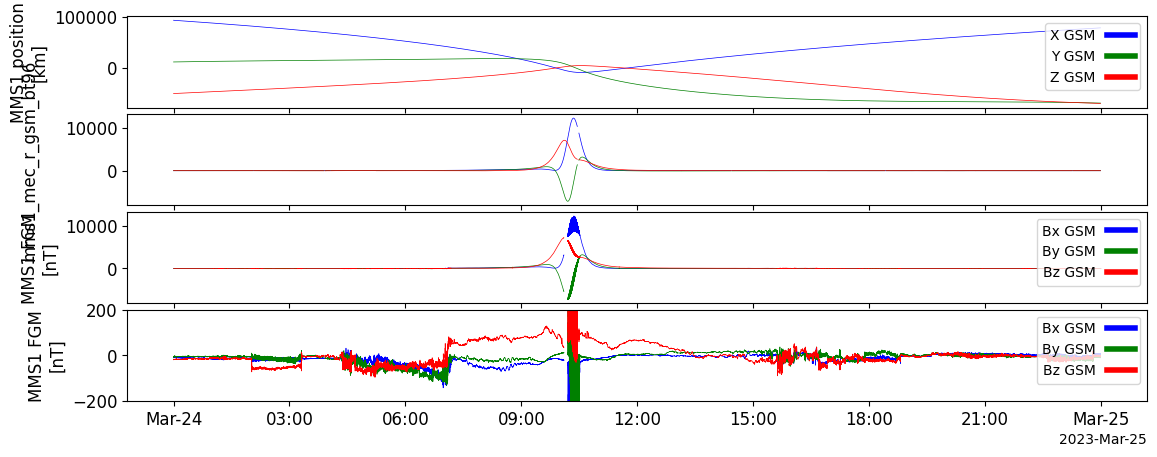

In [6]:
# (ORIG)
# Idealized developer minutes: 7+?

import pyspedas
from pyspedas.geopack import tt96, get_tsy_params
from pytplot import tplot,join_vec, time_double

def get_params(trange):
    support_trange = [time_double(trange[0])-60*60*24, 
                      time_double(trange[1])+60*60*24]
    pyspedas.kyoto.dst(trange=support_trange)
    pyspedas.omni.data(trange=support_trange)
    join_vec(['BX_GSE', 'BY_GSM', 'BZ_GSM'])
    return get_tsy_params('kyoto_dst',
                    'BX_GSE-BY_GSM-BZ_GSM_joined',
                    'proton_density',
                    'flow_speed',
                    model='t96',
                    pressure_tvar='Pressure',
                    g_variables=None,
                    speed=True)

trange=["2023-03-24","2023-03-25"]
parmod = get_params(trange)
mec_vars = pyspedas.mms.mec(probe='1',trange=trange)

# mms1_mec_r_gsm

fgm_vars = pyspedas.mms.fgm(probe='1',trange=trange, data_rate='srvy')

tt96('mms1_mec_r_gsm',parmod)

subtract('mms1_fgm_b_gsm_srvy_l2_bvec','mms1_mec_r_gsm_bt96','mag_diff')

options('mag_diff', 'yrange', [-200.0, 200.0])
tplot(['mms1_mec_r_gsm','mms1_mec_r_gsm_bt96', 'mms1_fgm_b_gsm_srvy_l2_bvec', 'mag_diff'])

#### Task 41: T96 Field Modeling Versus MMS Observations (NEW)
 - **Description:** Compare T96 model values to real MMS observations. Using pySPEDAS, load MMS orbit data for probe 1 on 2023-03-24, in GSM coordinates. Then download T96 model parameters from OMNI and the Kyoto WDC. Then, using the T96 model, generate the expected field at the MMS-1 times and GSM positions (using the downloaded model parameters). Then load MMS-1 FGM survey data in GSM coordinates for the same time range. Calculate the difference between the observed and modeled field variables using `pytplot.subtract()`. Set the `yrange` of the difference variable to `[-200.0, 200.0] nT`. Plot the position variable, modeled field variable, observed field variable, and observed-modeled field difference.

 Use this helper function:
 ```python
from pyspedas.geopack import get_tsy_params
from pytplot import time_double

def get_params(trange, position_var):
    support_trange = [time_double(trange[0])-60*60*24, 
                      time_double(trange[1])+60*60*24]
    pyspedas.kyoto.dst(trange=support_trange)
    pyspedas.omni.data(trange=support_trange)
    join_vec(['BX_GSE', 'BY_GSM', 'BZ_GSM'])
    parmod = get_tsy_params('kyoto_dst',
                            'BX_GSE-BY_GSM-BZ_GSM_joined',
                            'proton_density',
                            'flow_speed',
                            model='t96',
                            pressure_tvar='Pressure',
                            g_variables=None,
                            speed=True)
    # The field models expect the model parameters to be supplied at the same timestamps
    # as the input positions, so we interpolate them with pyspedas.tinterpol()
    pyspedas.tinterpol(parmod,position_var,newname='parmod_interpolated')
    return 'parmod_interpolated'
 ```
 - **Expected Learning Outcome:** How to compare MMS to the T96 field model.
 - **Hints:** pyspedas.mms.mec() (output variable: 'mms1_mec_r_gsm'); from pyspedas.geopack import tt96; tt96(position_variable,params) (output variable: position variable + _t96'); pyspedas.mms.fgm(), data_rate,='srvy' (output variable: 'mms1_b_gsm_srvy_l2'); pytplot.options, 'yrange'

20-May-24 20:29:34: Loading pydata/mms1/mec/srvy/l2/epht89q/2023/03/mms1_mec_srvy_l2_epht89q_20230324_v2.2.0.cdf
20-May-24 20:29:38: **************************************************************************************
20-May-24 20:29:38: The DST data are provided by the World Data Center for Geomagnetism, Kyoto, and
20-May-24 20:29:38:  are not for redistribution (http://wdc.kugi.kyoto-u.ac.jp/). Furthermore, we thank
20-May-24 20:29:38:  the geomagnetic observatories (Kakioka [JMA], Honolulu and San Juan [USGS], Hermanus
20-May-24 20:29:38:  [RSA], Alibag [IIG]), NiCT, INTERMAGNET, and many others for their cooperation to
20-May-24 20:29:38:  make the Dst index available.
20-May-24 20:29:38: **************************************************************************************
20-May-24 20:29:38: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/omni/omni_cdaweb/hro2_1min/2023/
20-May-24 20:29:39: File is current: omni_data/hro2_1min/2023/omni_hro2_1min_20230301_v01.cdf


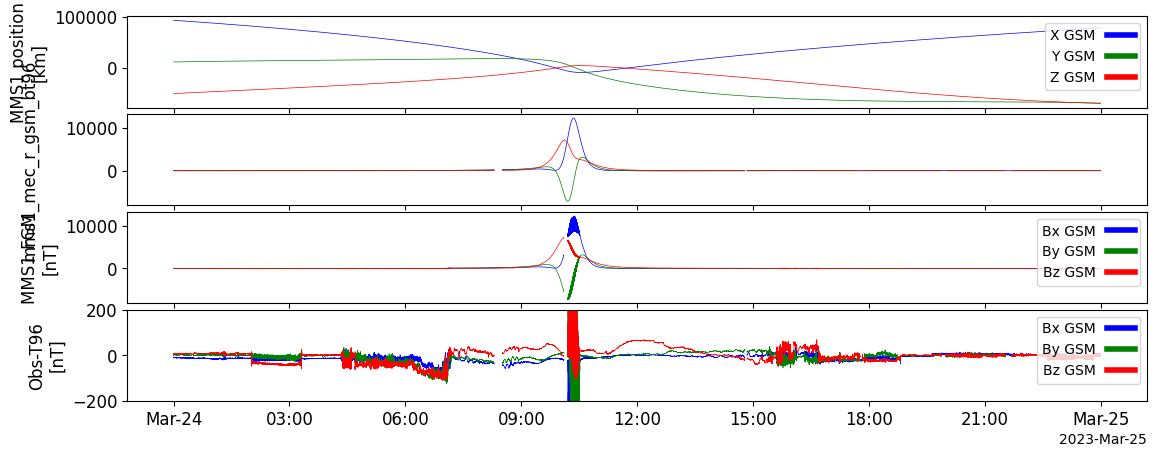

In [4]:
# (NEW)
# Idealized developer minutes: 7+?

import pyspedas
from pyspedas.geopack import tt96, get_tsy_params
from pytplot import tplot, join_vec, time_double, subtract, options

def get_params(trange, position_var):
    support_trange = [time_double(trange[0])-60*60*24,
                      time_double(trange[1])+60*60*24]
    pyspedas.kyoto.dst(trange=support_trange)
    pyspedas.omni.data(trange=support_trange)
    join_vec(['BX_GSE', 'BY_GSM', 'BZ_GSM'])
    parmod = get_tsy_params('kyoto_dst',
                            'BX_GSE-BY_GSM-BZ_GSM_joined',
                            'proton_density',
                            'flow_speed',
                            model='t96',
                            pressure_tvar='Pressure',
                            g_variables=None,
                            speed=True)
    pyspedas.tinterpol(parmod,position_var,newname='parmod_interpolated')
    return 'parmod_interpolated'

trange=["2023-03-24","2023-03-25"]

mec_vars = pyspedas.mms.mec(probe='1',trange=trange)
parmod = get_params(trange,'mms1_mec_r_gsm')

# mms1_mec_r_gsm

fgm_vars = pyspedas.mms.fgm(probe='1',trange=trange, data_rate='srvy')

tt96('mms1_mec_r_gsm',parmod)

subtract('mms1_fgm_b_gsm_srvy_l2_bvec','mms1_mec_r_gsm_bt96',newname='mag_diff')

options('mag_diff', 'yrange', [-200.0, 200.0])
options('mag_diff', 'ytitle', 'Obs-T96')
tplot(['mms1_mec_r_gsm','mms1_mec_r_gsm_bt96', 'mms1_fgm_b_gsm_srvy_l2_bvec', 'mag_diff'])

### SunPy

#### Task 42: Make a Movie of Today's SDO AIA Solar Imagery
 - **Description:** Make a short movie or loop using AIA 0095 A images from midnight today till "now".
 - **Expected Learning Outcome:** Sampling and how many frames to include. Using plot functions to generate short loops. Dealing with cadence mismatches, mismatches, and dropped frames.
 - **Hints:** Download files then create a MapSequence from them and animate them.

In [ ]:
# Idealized developer minutes: 7-8

# !pip install jupyterlab_play_cell_button
# !pip install ipympl
%matplotlib widget
# import jupyterlab_play_cell_button

from datetime import datetime, timedelta
import sunpy.map
from sunpy.net import Fido, attrs as a
import astropy.units as u
from astropy.visualization import ImageNormalize, SqrtStretch
import matplotlib.pyplot as plt

# Time range of today - now
time_start = datetime.now().strftime("%Y-%m-%d")
time_end = datetime.now().strftime("%Y-%m-%dT%H:%M:%S")

# Search for SDO images within the specified time range
results = Fido.search(a.Time(time_start, time_end), a.Instrument.aia, a.Wavelength(171*u.angstrom))

# Download the results
files = Fido.fetch(results[0, 0:100])
files.sort()

# Create a MapSequence and animate
sequence = sunpy.map.Map(files, sequence=True)

fig = plt.figure()
ax = fig.add_subplot(projection=sequence.maps[0])
ani = sequence.plot(axes=ax, norm=ImageNormalize(vmin=0, vmax=5e3, stretch=SqrtStretch()))

plt.show()

#### Task 43: Difference Image
 - **Description:** Pick 2 consecutive EUV images from SDO or STEREO and create a difference image (subtract the 2 to see what changed during that time step).
 - **Expected Learning Outcome:** Understand image scaling, alignment, and what a difference image is.
 - **Hints:** Calculate times for selecting pre-flare and post-flare images. Use SunPy's Fido for image retrieval, and then create a difference image by subtracting one from the other to visualize changes.

In [ ]:
# Idealized developer minutes: 10?

#https://docs.sunpy.org/en/stable/generated/gallery/map/difference_images.html#sphx-glr-generated-gallery-map-difference-images-py

from datetime import datetime, timedelta

# Solar flare peak time in EST
flare_peak_est = datetime(2024, 2, 22, 17, 34)

# Convert EST to UTC (EST is UTC-5)
flare_peak_utc = flare_peak_est + timedelta(hours=5)

# Calculate times for image retrieval
pre_flare_time = flare_peak_utc - timedelta(minutes=60)
post_flare_time = flare_peak_utc + timedelta(minutes=0)

flare_peak_utc, pre_flare_time, post_flare_time

# -----------------------------

from sunpy.net import Fido, attrs as a
import sunpy.map
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.visualization.wcsaxes import WCSAxes

# Define the search query for the pre-flare and post-flare images
results = Fido.search(a.Time(pre_flare_time, post_flare_time),
                         a.Instrument.aia,
                         a.Wavelength(195*u.angstrom))
# display(results[0,0])
# display(results[0,-1])
# Assuming the results variable contains the search results,
# download only the first and last images
files = Fido.fetch(results[0, 0], results[0, -1])

# Load the images as SunPy Maps
maps = sunpy.map.Map(files, sequence=True)

# Perform the differencing
diff_map = maps[1].data - maps[0].data

# Create a new SunPy Map for the difference image using the metadata from the first image
diff_map = sunpy.map.Map(diff_map, maps[0].meta)

# Assuming `maps` is a SunPy MapSequence or list of SunPy Map objects
fig = plt.figure(figsize=(15, 5))

# Create three subplots with WCS projection
ax1 = fig.add_subplot(1, 3, 1, projection=maps[0].wcs)
maps[0].plot(axes=ax1, title='Pre-flare Image')

ax2 = fig.add_subplot(1, 3, 2, projection=maps[1].wcs)
maps[1].plot(axes=ax2, title='Post-flare Image')

ax_diff = fig.add_subplot(1, 3, 3, projection=maps[0].wcs)  # Use the projection from one of the maps
diff_map.plot(axes=ax_diff, title='Difference Image')

plt.show()